EXTRACTING DATA from PLOT: EVENT COUNT PER 0.425 Mev ENERGY BIN VS. PROMT ENERGY

In [1]:

#uploading the data from digitized plot1
from google.colab import files
uploaded = files.upload()

Saving data.xlsx to data.xlsx


In [2]:
#header files
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt

In [3]:
#making a dataframe in pandas with the data from the uploaded excel file
df = pd.read_excel("data.xlsx")
print (df)

           bins         x          y        Nmc
0   2.600-3.025  2.819277   6.992310  16.419230
1   3.025-3.450  3.253012  11.011540  15.615380
2   3.450-3.875  3.662651   8.965385  13.642308
3   3.875-4.300  4.084338   7.942307  11.157695
4   4.300-4.725  4.530120   8.015388   9.330772
5   4.725-5.150  4.951807   3.923076   6.919234
6   5.150-5.575  5.385542   4.873079   5.019230
7   5.575-6.000  5.819277   1.950002   3.411540
8   6.000-6.425  6.216867   0.050003   2.169235
9   6.425-6.850  6.638554   0.123079   1.292309
10  6.850-7.275  7.072289   0.000000   0.488464


In [4]:
index_to_drop = [10]
df= df.drop(index_to_drop) #eliminating 0 inputs

In [5]:
#converting required columns to numpy
#column x entries are the middle point of the energy bins column y entries are the no of events for that energy bins. colimn Nmc is the expected no of events for no oscillation case.
data = df[["x","y", "Nmc"]].to_numpy()
print (data)

[[ 2.81927743  6.99231016 16.41923018]
 [ 3.25301216 11.01154034 15.61537968]
 [ 3.66265087  8.96538456 13.64230807]
 [ 4.08433759  7.94230667 11.15769472]
 [ 4.53012033  8.01538805  9.33077191]
 [ 4.95180705  3.92307649  6.91923436]
 [ 5.38554178  4.87307858  5.01923018]
 [ 5.81927743  1.95000209  3.41154034]
 [ 6.21686721  0.05000348  2.16923506]
 [ 6.63855393  0.12307928  1.29230876]]


INTRODUCING VARIABLES

In [6]:
#experimental data for plot 1
E = data[:,0]#promt energy
event_count_exp= data[:,1]#experimental data
Nmc= data[:,2]#no scillition data or monte carlo simulation data

In [7]:

#Ratio of number of event data recieved(excluding 1 background data) and the expected number of event data expected when there is NO OSCILLATION

'''R_obs with errors = 0.611 +- sigma_stat += sigma_sys
sigma_stat is statistical and sigma_sys includes all the systemic uncertainity'''

sigma_stat, sigma_sys= 0.085, 0.041
R_obs = 0.611   #source:


CHI SQUARE CONSTRUCTION:
(\chi^2)_total = (\chi^2)_rate + (\chi^2)_shape

In [8]:
#with pull for systemic error
#defining chi square
def chi_square_final(parameters, E, Nmc):
  sin2theta12_square, dm12_square, alpha= parameters
  event_count_model_prob = (1- (sin2theta12_square)*((np.sin(1270*(dm12_square)*180/E))**2))
  R_th = event_count_model_prob.sum()/len(event_count_model_prob)
  u_i = (event_count_model_prob*Nmc)

  #a pull term is added in the chi square expression to consider the total systematic uncertainity for th distribution
  u_i_with_pull= (1 + alpha)*u_i
  sigma_alpha = 0.064 #source:

  chi2_rate = 2*(np.sum(R_obs - R_th)**2)/(sigma_stat**2 + sigma_sys**2) #the systematic error is already added for chi2_rate here, so no pull term is required for this expression.

  chi2_shape_with_pull = 2*(np.sum( u_i_with_pull -event_count_exp + (event_count_exp)* (np.log((event_count_exp)/ u_i_with_pull)))) + (alpha / sigma_alpha) **2
  chi2_final = chi2_rate + chi2_shape_with_pull
  return chi2_final

CHI SQUARE MINIMIZATION AND BEST VALUES ESTIMATION

In [9]:
#minimizing chi square


pi = [0.7,6e-5, 0.0]  #initial guess
result = minimize(chi_square_final, pi, args=( E, Nmc))
best_sin2theta12_square, best_dm12_square, best_alpha = result.x #best fit for the parameters
dof= (len(E))-3 #dof = No of data point- no of parameters
print("dof =", dof)
print ("del chi square/ dof = ", (result.fun)/dof)

print ("sin2theta12 square and delm square are ",best_sin2theta12_square, best_dm12_square)#parameters
best_survival_prob_th = (1- (best_sin2theta12_square)*((np.sin(1270*(best_dm12_square)*180/E))**2))
best_R_th = best_survival_prob_th.sum()/len(best_survival_prob_th)
print("best R_th= ", best_R_th)
chi2_min = result.fun
print("chi2 best value= ",(chi2_min))#chi square value

dof = 7
del chi square/ dof =  0.8153014691502508
sin2theta12 square and delm square are  0.744548661607577 5.30894583678182e-05
best R_th=  0.6298907859597909
chi2 best value=  5.707110284051756


In [10]:
#total number of events

print("no from kamland data: ",np.sum(event_count_exp))#kamland data
print("no for MC estimation without oscillation: ", np.sum(Nmc))#without oscillation

#with oscillation using best fit
event_count_model_prob = (1- (best_sin2theta12_square)*((np.sin(1270*(best_dm12_square)*180/E))**2))
u_i = (event_count_model_prob*Nmc)
u_i_with_pull= (1 + best_alpha)*u_i
print("no from model estimation: ",np.sum(u_i_with_pull))

no from kamland data:  53.84616971438913
no for MC estimation without oscillation:  84.97693326261457
no from model estimation:  59.23845517433797


parameters contour

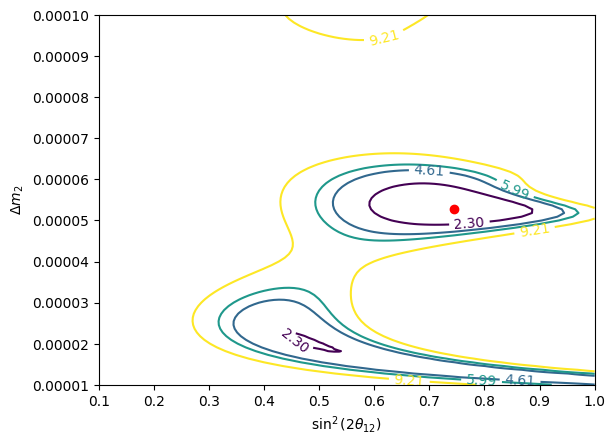

In [11]:
#Parametric contour plots for confidence levels


dm2_vals = np.linspace(1e-5, 1e-4, 100)
s2_vals  = np.linspace(0.1, 1.0, 100)
chi2 = np.zeros((len(dm2_vals), len(s2_vals)))

for i, dm2 in enumerate(dm2_vals):
    for j, s2 in enumerate(s2_vals):
        pi = [s2, dm2, best_alpha] #alpha in the pull term is not considered a parameter in this contour plot. so we use the best_alpha value for alpha. The other two acts here as true parameters.
        chi2[i, j] = chi_square_final(pi, E, Nmc)
delta_chi2 = chi2 - chi2_min

S2,DM2 = np.meshgrid(s2_vals, dm2_vals)

levels = [2.30, 4.61, 5.99, 9.21] #2 parametric del chi square values for confidence levels
cs = plt.contour(S2, DM2, delta_chi2, levels=levels)
plt.clabel(cs, inline=True)

min_index = np.unravel_index(np.argmin(chi2), chi2.shape)
plt.plot(s2_vals[min_index[1]], dm2_vals[min_index[0]], 'ro')

plt.xlabel(r'$\sin^2(2\theta_{12})$')
plt.ylabel(r'$\Delta m_{2}$')
plt.show()